<font size = 10>\
    Projet 4 - Build a scoring model

Import usefull package

In [529]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectFromModel

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_validate,cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold,RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from sklearn.datasets import make_classification

from sklearn.dummy import DummyClassifier

from sklearn.utils import resample

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA

from sklearn.kernel_ridge import KernelRidge

from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.base import BaseEstimator

# Load dataset

## Working with the Loan appplication data set

### Data

In [2]:
app_data = pd.read_csv('data/application_train.csv')
print('Training data shape: ', app_data.shape)

Training data shape:  (307511, 122)


### Kaggle Testing dataset

In [3]:
app_kaggle = pd.read_csv('data/application_test.csv')
print('Testing data shape: ', app_kaggle.shape)

Testing data shape:  (48744, 121)


# Exploratory Data Analysis

## Distribution of the target

In [17]:
app_data['TARGET'].value_counts()

0    282686
1     24825
Name: TARGET, dtype: int64

## Missing values

In [18]:
(app_data.isna().sum(axis = 0) / app_data.shape[0]).sort_values(ascending=False)[0:20]

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MEDI               0.593767
dtype: float64

## Feature types

In [19]:
app_data.dtypes.value_counts()

float64    65
int64      41
object     16
dtype: int64

### Encoding Categorical Variables

Encode with labelEncoder for 2 unique categories or use get_dumies

In [78]:
from sklearn.preprocessing import LabelEncoder


# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_data:
    if app_data[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_data[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_data[col])
            # Transform both training and testing data
            app_data[col] = le.transform(app_data[col])
            app_kaggle[col] = le.transform(app_kaggle[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [79]:
# one-hot encoding of categorical variables
app_data = pd.get_dummies(app_data)
app_kaggle = pd.get_dummies(app_kaggle)

print('Training Features shape: ', app_data.shape)
print('Testing Features shape: ', app_kaggle.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


In [80]:
train_labels = app_data['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_data, app_kaggle = app_data.align(app_kaggle, join = 'inner', axis = 1)

# Add the target back in
app_data['TARGET'] = train_labels

print('Training Features shape: ', app_data.shape)
print('Testing Features shape: ', app_kaggle.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


In [81]:
app_data.to_pickle('data/app_data_encode_categ')
app_kaggle.to_pickle('data/app_kaggle_encode_categ')

In [82]:
app_data.shape

(307511, 240)

In [83]:
app_kaggle.shape

(48744, 239)

### Outliers in numerical features

In [84]:
app_data=pd.read_pickle('data/app_data_encode_categ')
app_kaggle=pd.read_pickle('data/app_kaggle_encode_categ')

In [85]:
app_data.shape

(307511, 240)

In [86]:
app_kaggle.shape

(48744, 239)

Print the describe function on the numerical columns to check for outliers

In [24]:
app_num=app_data.select_dtypes(include=['float64','int64'])

In [25]:
def show_describe(i):
    return app_num.describe().iloc[:,(i-1)*10:i*10]

In [26]:
widgets.interact(show_describe, i=10)

interactive(children=(IntSlider(value=10, description='i', max=30, min=-10), Output()), _dom_classes=('widget-…

<function __main__.show_describe(i)>

In [87]:
suspected_outliers=['DAYS_EMPLOYED',
                    'OBS_30_CNT_SOCIAL_CIRCLE',
                    'DEF_30_CNT_SOCIAL_CIRCLE',
                    'OBS_60_CNT_SOCIAL_CIRCLE',
                    'DEF_60_CNT_SOCIAL_CIRCLE',
                    'AMT_REQ_CREDIT_BUREAU_HOUR',
                    'AMT_REQ_CREDIT_BUREAU_DAY',
                    'AMT_REQ_CREDIT_BUREAU_WEEK',
                    'AMT_REQ_CREDIT_BUREAU_MON',
                    'AMT_REQ_CREDIT_BUREAU_QRT',
                    'AMT_REQ_CREDIT_BUREAU_YEAR',
                    'HOUR_APPR_PROCESS_START'
                   ]

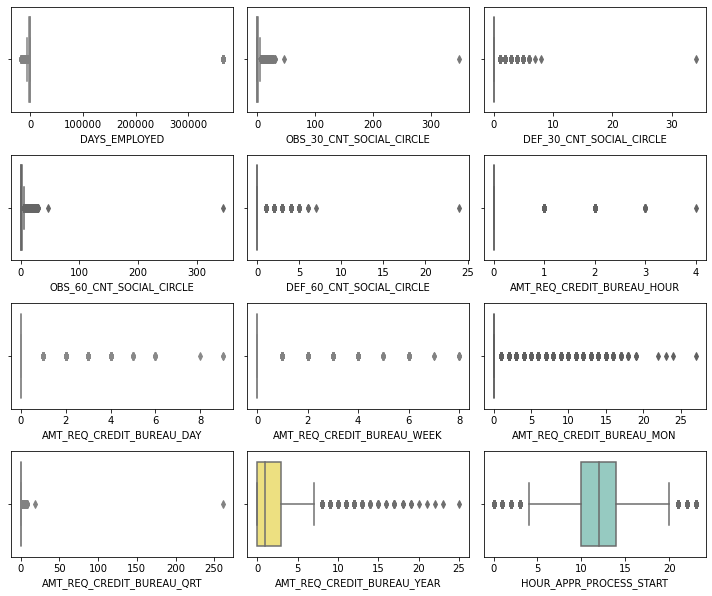

In [29]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

#### DAYS_EMPLOYED

In [88]:
app_data[app_data['DAYS_EMPLOYED']>200000].shape

(55374, 240)

<AxesSubplot:xlabel='DAYS_EMPLOYED'>

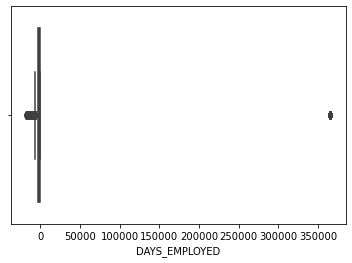

In [31]:
sns.boxplot(x=app_data['DAYS_EMPLOYED'])

In [97]:
# Create an anomalous flag column
app_data['DAYS_EMPLOYED_ANOM'] = app_data["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_data['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

# Apply the same steps to the test data
app_kaggle['DAYS_EMPLOYED_ANOM'] = app_kaggle["DAYS_EMPLOYED"] == 365243
app_kaggle["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)



#### Social circle features

In [98]:
app_data[app_data['OBS_30_CNT_SOCIAL_CIRCLE']>100].shape

(0, 241)

In [99]:
app_data.drop(index=app_data[app_data['OBS_30_CNT_SOCIAL_CIRCLE']>100].index,inplace=True)

<AxesSubplot:xlabel='DEF_30_CNT_SOCIAL_CIRCLE'>

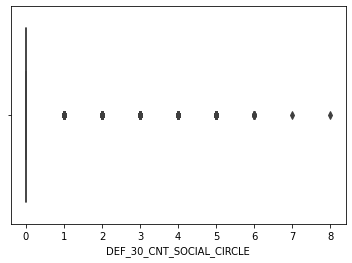

In [35]:
sns.boxplot(x=app_data['DEF_30_CNT_SOCIAL_CIRCLE'])

In [100]:
app_data[(app_data['DEF_30_CNT_SOCIAL_CIRCLE']>1.5) & (app_data['DEF_30_CNT_SOCIAL_CIRCLE']<2.5)].shape

(5323, 241)

In [101]:
app_data[(app_data['OBS_30_CNT_SOCIAL_CIRCLE']>15) & (app_data['OBS_30_CNT_SOCIAL_CIRCLE']<25)].shape

(418, 241)

<AxesSubplot:xlabel='DEF_60_CNT_SOCIAL_CIRCLE', ylabel='OBS_60_CNT_SOCIAL_CIRCLE'>

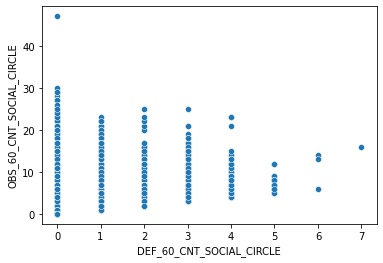

In [38]:
sns.scatterplot(x=app_data['DEF_60_CNT_SOCIAL_CIRCLE'],y=app_data['OBS_60_CNT_SOCIAL_CIRCLE'])

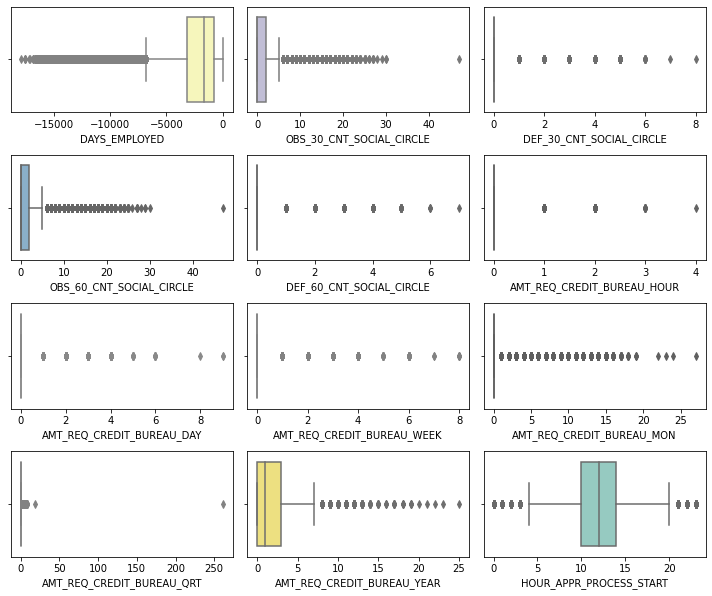

In [40]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

#### Amount of request features

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

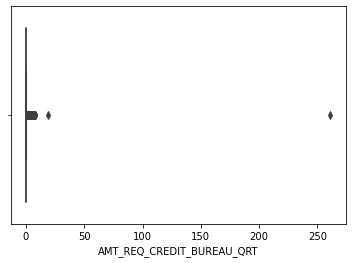

In [94]:
sns.boxplot(x=app_data['AMT_REQ_CREDIT_BUREAU_QRT'])

In [102]:
app_data[app_data['AMT_REQ_CREDIT_BUREAU_QRT']>15].shape

(0, 241)

In [103]:
app_data.drop(index=app_data[app_data['AMT_REQ_CREDIT_BUREAU_QRT']>15].index,inplace=True)

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

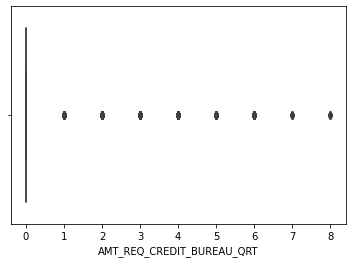

In [46]:
sns.boxplot(x=app_data['AMT_REQ_CREDIT_BUREAU_QRT'])

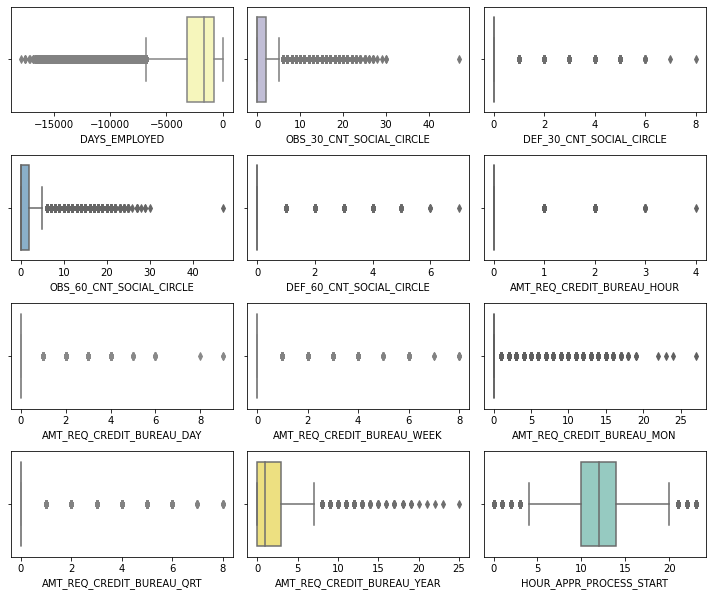

In [47]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

## SK_ID_CURR

In [315]:
app_data.index = app_data['SK_ID_CURR']
app_kaggle.index = app_kaggle['SK_ID_CURR']

In [317]:
app_data = app_data.drop(columns=['SK_ID_CURR'])
app_kaggle = app_kaggle.drop(columns=['SK_ID_CURR'])

## Saving datasets

In [320]:
app_data.to_pickle('data/app_data_outliers')
app_kaggle.to_pickle('data/app_kaggle_outliers')

## Correlations

In [18]:
app_data=pd.read_pickle('data/app_data_outliers')
app_kaggle=pd.read_pickle('data/app_kaggle_outliers')
print('app_data shape :', app_data.shape)
print('app_kaggle shape :',app_kaggle.shape)

app_data shape : (307508, 240)
app_kaggle shape : (48744, 239)


In [19]:
#correlation_matrix=app_data.corr()

In [24]:
#correlation_matrix.fillna(0,inplace=True)

In [25]:
#correlation_matrix.to_pickle('data/correlation_matrix')

In [97]:
correlation_matrix=pd.read_pickle('data/correlation_matrix')

In [98]:
#get index and columns
I = correlation_matrix.index
C = correlation_matrix.columns

# fills the diagonal with,get absolute value and upper triangle
np.fill_diagonal(correlation_matrix.values,0)
correlation_abs_matrix = correlation_matrix.abs()
correlation_abs_matrix = pd.DataFrame(np.triu(correlation_abs_matrix),index=I,columns=C)

Let's look at the value over 0.95

In [99]:
couples=[]
for row in correlation_abs_matrix.index:
    for col in correlation_abs_matrix.columns:
        if correlation_abs_matrix.loc[row,col] > 0.95:
            couples.append([row,col,correlation_abs_matrix.loc[row,col]])
couples = pd.DataFrame(couples,columns=['feature_1','feature_2','corr'])

In [100]:
couples.sort_values(by='corr',ascending=False)

,feature_1,feature_2,corr
47,CODE_GENDER_F,CODE_GENDER_M,0.999971
2,FLAG_EMP_PHONE,ORGANIZATION_TYPE_XNA,0.999868
48,NAME_INCOME_TYPE_Pensioner,ORGANIZATION_TYPE_XNA,0.999648
1,FLAG_EMP_PHONE,NAME_INCOME_TYPE_Pensioner,0.999515
11,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
46,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998380
21,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
19,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
17,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
15,ELEVATORS_AVG,ELEVATORS_MEDI,0.996099


In [101]:
app_data_corr = app_data.drop(columns=couples['feature_1'])
app_kaggle_corr = app_data.drop(columns=couples['feature_1'])

# Baseline

In [105]:
def show_score(y_test,y_pred_d_cls_prob,y_pred_d_cls):
    a=roc_auc_score(y_test,y_pred_d_cls_prob)
    b=f1_score(y_test,y_pred_d_cls)
    c=accuracy_score(y_test,y_pred_d_cls)
    d=precision_score(y_test,y_pred_d_cls)
    e=recall_score(y_test,y_pred_d_cls)
    print('ROC AUC   :',a)
    print('F1        :',b)
    print('Accuracy  :',c)
    print('Precision :',d)
    print('Recall    :',e)

## Test and Train split

In [131]:
X = app_data.drop( columns = ['TARGET'])
y = app_data['TARGET']
features = X.columns

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [133]:
y_test.shape

(46127,)

## Undersampling

In [134]:
X_train_under, y_train_under = resample(X_train,y_train,n_samples = 10000, stratify = y_train,random_state=2)

## Dummy classifier

In [135]:
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=2,random_state=5)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}

In [136]:
dummy_cls = Pipeline( [('imp' , SimpleImputer(strategy='median')),
                       ('scaler' , StandardScaler()),
                       ('Dummy_cls', DummyClassifier(strategy='stratified'))])

In [137]:
scores = cross_validate(dummy_cls,X_train_under,y_train_under, scoring = scoring, cv=cv)
for key in scores.keys():
    print (f'Mean {key} : {scores[key].mean()}' )

Mean fit_time : 0.4731558561325073
Mean score_time : 0.08415284156799316
Mean test_ROC AUC : 0.49813161388209687
Mean test_F1 : 0.0715207877749882
Mean test_Accuracy : 0.85215
Mean test_Precision : 0.07269225476130645
Mean test_Recall : 0.07063492063492063


In [138]:
dummy_cls.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('Dummy_cls', DummyClassifier(strategy='stratified'))])

In [267]:
scores={}

In [142]:
show_score(y_test,dummy_cls.predict_proba(X_test)[:,1],dummy_cls.predict(X_test))

ROC AUC   : 0.4995044912168236
F1        : 0.08502078583880916
Accuracy  : 0.8520822945346543
Precision : 0.08503218884120171
Recall    : 0.08500938589434165


## Kaggle Submission

In [470]:
def kaggle_submit(estimator,data,output_name = 'submission_default.csv'):
    kaggle_pred = estimator.predict_proba(data)[:,1]
    kaggle_df = pd.DataFrame(data.index,columns=['SK_ID_CURR'])
    kaggle_df['TARGET'] = kaggle_pred
    kaggle_df.to_csv('data/'+output_name,index = False)

# Feature Importance

In [234]:
def features_importance_lg(estimator,features,n_features_plot = 40,n_features_cum = 100,plot = False):
    
    estimator_coef=pd.DataFrame(estimator.coef_.reshape(features.shape[0],),columns=['coeff'])
    estimator_coef['abs_coeff']=np.abs(estimator_coef['coeff'])
    estimator_coef['relative_importance']=estimator_coef['coeff'] / estimator_coef['abs_coeff'].sum()
    estimator_coef['abs_relative_importance']=estimator_coef['abs_coeff']/estimator_coef['abs_coeff'].sum()
    estimator_coef['sign']=np.sign(estimator_coef['coeff'])
    estimator_coef['feature']=features.values
    estimator_coef = estimator_coef.sort_values(by='abs_relative_importance',ascending=False)
    estimator_coef['cum_sum_abs_rel_imp']=np.cumsum(estimator_coef['abs_relative_importance'])
    
    if plot == True:
        plt.figure(figsize=(7,7))
        sns.barplot(data=estimator_coef.head(n_features_plot),x ='relative_importance',y='feature',hue='sign',dodge=False)
        sns.relplot(data=estimator_coef.head(n_features_cum),y ='cum_sum_abs_rel_imp',x=np.arange(1,n_features_cum+1),kind='line')
        plt.ylabel('cumulative feature importance')
        plt.xlabel('number of features')
    return estimator_coef

In [235]:
def features_importance_rdf(estimator,features,n_features_plot = 40,n_features_cum = 100, plot = False):
    
    estimator_coef=pd.DataFrame(estimator.feature_importances_.reshape(features.shape[0],),columns=['coeff'])
    estimator_coef['importance']=np.abs(estimator_coef['coeff'])
    estimator_coef['abs_relative_importance']=estimator_coef['importance']/estimator_coef['importance'].sum()
    estimator_coef['sign']=np.sign(estimator_coef['coeff'])
    estimator_coef['feature']=features.values
    estimator_coef = estimator_coef.sort_values(by='abs_relative_importance',ascending=False)
    estimator_coef['cum_sum_abs_rel_imp']=np.cumsum(estimator_coef['abs_relative_importance'])
    
    if plot == True:
        plt.figure(figsize=(7,7))
        sns.barplot(data=estimator_coef.head(n_features_plot),x ='abs_relative_importance',y='feature',hue='sign',dodge=False)
        sns.relplot(data=estimator_coef.head(n_features_cum),y ='cum_sum_abs_rel_imp',x=np.arange(1,n_features_cum+1),kind='line')
        plt.ylabel('cumulative feature importance')
        plt.xlabel('number of features')
    return estimator_coef

In [208]:
feature_importance={}

## Decision tree

In [209]:
pipeline_tree = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('tree' , DecisionTreeClassifier(class_weight='balanced'))]) 
                        

In [210]:
pipeline_tree.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('tree', DecisionTreeClassifier(class_weight='balanced'))])

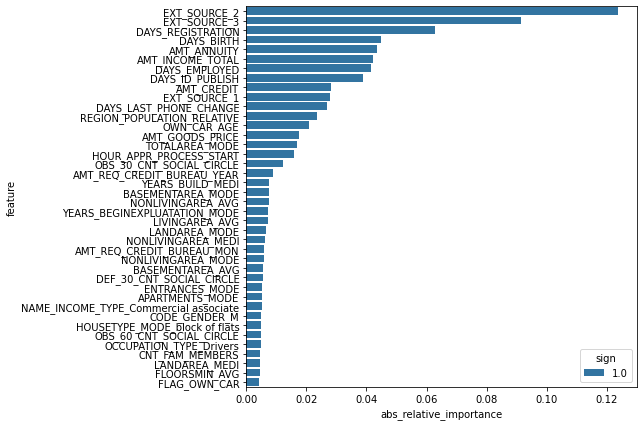

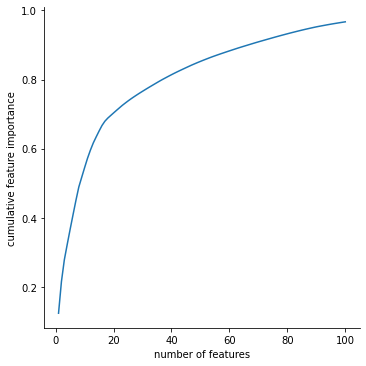

In [236]:
feature_importance['tree'] = features_importance_rdf(pipeline_tree.named_steps['tree'],features,plot=True)

## LDA

In [212]:
pipeline_lda = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('lda' , LinearDiscriminantAnalysis())]) 

In [213]:
pipeline_lda.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lda', LinearDiscriminantAnalysis())])

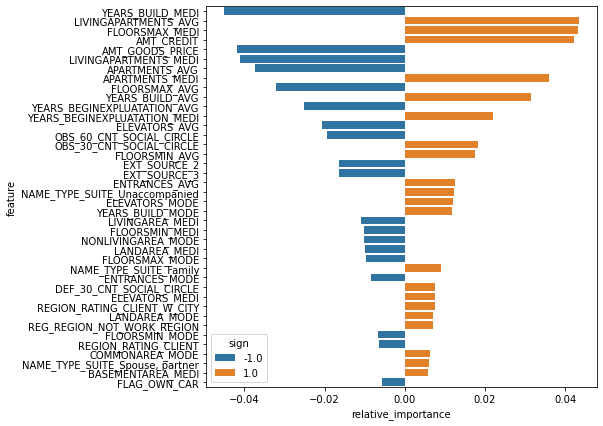

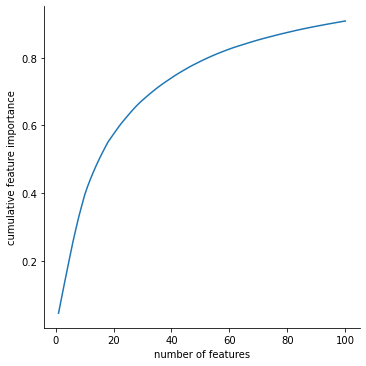

In [237]:
feature_importance['lda'] = features_importance_lg(pipeline_lda.named_steps['lda'],features,plot=True)

## Logistic regression

In [217]:
pipeline_lr = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('lr' , LogisticRegression(C = 0.01, max_iter = 200, class_weight = 'balanced'))]) 

In [218]:
pipeline_lr.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=200))])

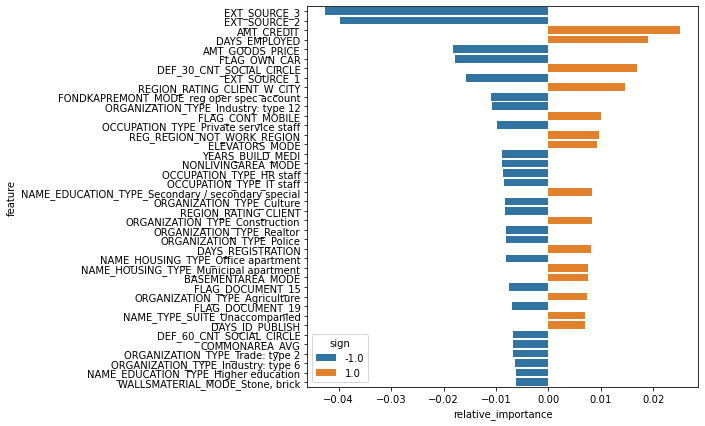

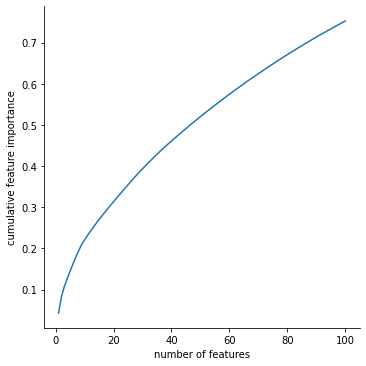

In [238]:
feature_importance['lr'] = features_importance_lg(pipeline_lr.named_steps['lr'],features,plot=True)

## Random forest

In [220]:
pipeline_rdf = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('rdf' , RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'))]) 

In [221]:
pipeline_rdf.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('rdf', RandomForestClassifier(class_weight='balanced'))])

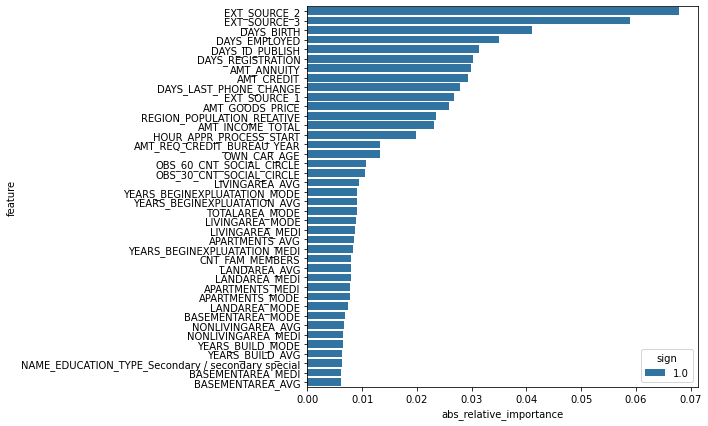

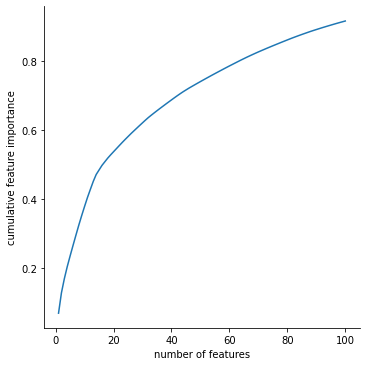

In [239]:
feature_importance['rdf'] = features_importance_rdf(pipeline_rdf.named_steps['rdf'],features,plot = True)

## SGD Classifier

In [223]:
pipeline_sgd = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('sgd' , SGDClassifier(class_weight='balanced',loss='modified_huber'))]) 

In [224]:
pipeline_sgd.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('sgd',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

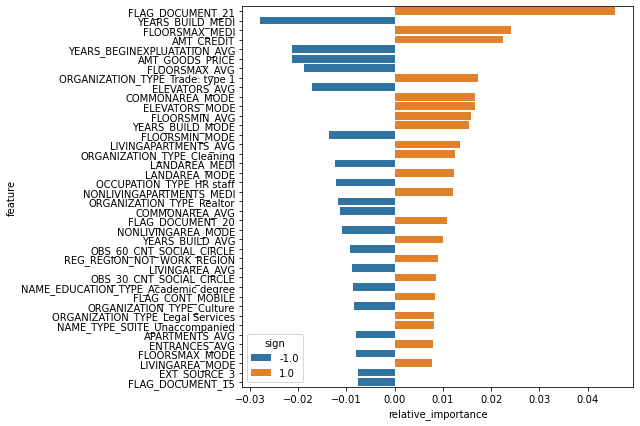

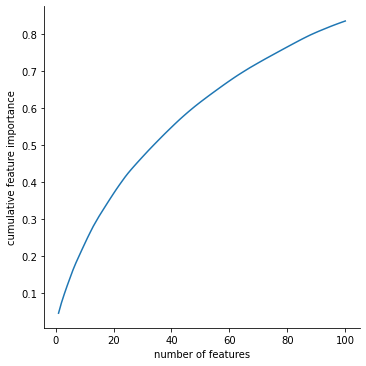

In [240]:
feature_importance['SGDClassifier'] = features_importance_lg(pipeline_sgd.named_steps['sgd'],features,plot = True)

## LGB

In [226]:
pipeline_lgb = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('lgb' , LGBMClassifier(class_weight='balanced'))]) 

In [227]:
pipeline_lgb.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lgb', LGBMClassifier(class_weight='balanced'))])

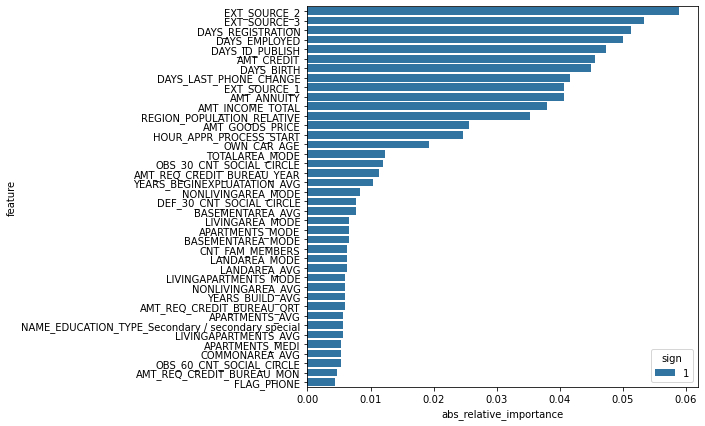

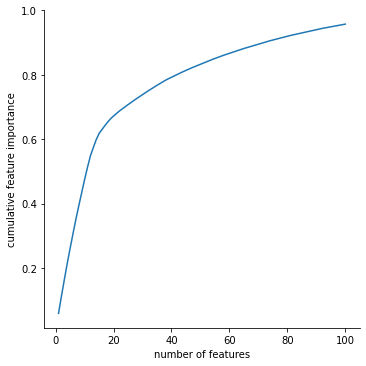

In [241]:
feature_importance['lgb'] = features_importance_rdf(pipeline_lgb.named_steps['lgb'],features,plot = True)

## Feature importance results

In [229]:
feature_importance.keys()

dict_keys(['tree', 'lda', 'lr', 'rdf', 'SGDClassifier', 'lgb'])

In [230]:
feature_importance_results = pd.DataFrame(index = features)
feature_importance_results['counts']=0
feature_importance_results['rank']=0
feature_importance_results['total importance']=0
feature_importance_results['appearance in top 40']=0

In [231]:
for key in feature_importance.keys():
    n = 0
    for feature in feature_importance[key]['feature']:
        if n <= 30:
            feature_importance_results.loc[feature,'counts']+=1
        feature_importance_results.loc[feature,'rank']+=n
        feature_importance_results.loc[feature,'total importance']+= feature_importance[key].where(feature_importance[key]['feature'] == feature )['abs_relative_importance'].sum()
        n+=1
feature_importance_results['total importance'] = feature_importance_results['total importance'] / feature_importance_results['total importance'].sum()
    

In [232]:
top_40_counts_index = feature_importance_results.sort_values(by=['counts'],ascending=False).head(40).index
feature_importance_results.loc[top_40_counts_index,'appearance in top 40']+=1

top_40_importance_index = feature_importance_results.sort_values(by=['total importance'],ascending=False).head(40).index
feature_importance_results.loc[top_40_importance_index,'appearance in top 40']+=1

top_40_rank_index = feature_importance_results.sort_values(by=['rank'],ascending=True).head(40).index
feature_importance_results.loc[top_40_rank_index,'appearance in top 40']+=1

In [233]:
feature_importance_results.sort_values(by=['appearance in top 40','total importance'],ascending=False).head(40)

,counts,rank,total importance,appearance in top 40
EXT_SOURCE_2,5,78,0.052056,3
EXT_SOURCE_3,5,58,0.045061,3
AMT_CREDIT,6,28,0.032143,3
DAYS_EMPLOYED,4,110,0.026030,3
DAYS_REGISTRATION,4,295,0.026008,3
AMT_GOODS_PRICE,6,48,0.025082,3
DAYS_ID_PUBLISH,3,212,0.021765,3
AMT_ANNUITY,3,295,0.020626,3
EXT_SOURCE_1,4,169,0.019817,3
YEARS_BUILD_MEDI,4,139,0.016346,3


## Reducing number of feature

In [242]:
score = 'f1'

### optimisation of number of feature

In [251]:
best_nb_feat = {}

In [243]:
params = {'feature_selection__max_features':np.arange(50,140,10)}

In [244]:
def opt_feat(estimator,params,X,y,score):
    pipeline = Pipeline([('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('feature_selection', SelectFromModel(estimator)),
                         ('estimator' , estimator)])
    CV = GridSearchCV(pipeline,
                      param_grid = params,
                      scoring = score,
                      verbose=True,
                      cv=5)
    CV.fit(X,y)
    print (f'{CV.best_params_}')
    return CV

#### Decision tree

In [245]:
CV_tree_max_feat = opt_feat(DecisionTreeClassifier(class_weight='balanced'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:   43.5s finished


{'feature_selection__max_features': 50}


In [252]:
best_nb_feat['tree'] = CV_tree_max_feat.best_params_['feature_selection__max_features']

#### LDA

In [246]:
CV_lda_max_feat = opt_feat(LinearDiscriminantAnalysis(),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:   45.8s finished


{'feature_selection__max_features': 50}


In [253]:
best_nb_feat['lda'] = CV_lda_max_feat.best_params_['feature_selection__max_features']

#### Logistic regression

In [247]:
CV_lr_max_feat = opt_feat(LogisticRegression(C = 0.01, max_iter = 1000, class_weight = 'balanced'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:   33.8s finished


{'feature_selection__max_features': 80}


In [254]:
best_nb_feat['lr'] = CV_lr_max_feat.best_params_['feature_selection__max_features']

#### Random Forest

In [248]:
CV_rdf_max_feat = opt_feat(RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:  3.4min finished


{'feature_selection__max_features': 50}


In [255]:
best_nb_feat['rdf'] = CV_rdf_max_feat.best_params_['feature_selection__max_features']

#### SGD

In [256]:
CV_sgd_max_feat = opt_feat(SGDClassifier(class_weight='balanced',loss='modified_huber'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:   45.7s finished


{'feature_selection__max_features': 110}


In [257]:
best_nb_feat['sgd'] = CV_sgd_max_feat.best_params_['feature_selection__max_features']

#### LGB

In [258]:
CV_lgb_max_feat = opt_feat( LGBMClassifier(class_weight='balanced'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:  1.5min finished


{'feature_selection__max_features': 50}


In [259]:
best_nb_feat['lgb'] = CV_lgb_max_feat.best_params_['feature_selection__max_features']

### Comparing performance

In [399]:
scores=pd.DataFrame(columns=['roc_auc_train','f1_train','roc_auc_test','f1_test'])

In [400]:
def compute_score(estimator,X_train,y_train,X_test,y_test,cv,label,number_fit=3):
    '''Compute the score of the estimator in the training set using cross validation
    and the score on the test set with number_fit fitting'''
    
    #compute scores on training set
    scores = cross_validate(estimator,X_train,y_train, scoring = {'ROC AUC': 'roc_auc','F1': 'f1'}, cv=cv)
    
    #fit and calculate scores on test set
    roc=[]
    f1=[]
    for i in range(number_fit):
        estimator.fit(X_train,y_train)
        y_pred_prob = estimator.predict_proba(X_test)[:,1]
        y_pred = estimator.predict(X_test)
        roc.append(roc_auc_score(y_test,y_pred_prob))
        f1.append(f1_score(y_test,y_pred))

    final_scores= [np.mean(scores['test_ROC AUC']),
                   np.mean(scores['test_F1']),
                   np.mean(roc),
                   np.mean(f1)]
    return pd.DataFrame([final_scores],columns=['roc_auc_train','f1_train','roc_auc_test','f1_test'],index=[label])                     

In [284]:
def create_pipeline_red(estimator,label,best_nb_feat):
    pipeline = Pipeline([('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('feature_selection', SelectFromModel(estimator,max_features=best_nb_feat[label])),
                         ('estimator' , estimator)])     
    return pipeline

#### Tree

In [401]:
pipeline_tree_red = create_pipeline_red(DecisionTreeClassifier(class_weight='balanced'),
                                       label='tree',
                                       best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_tree_red,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='tree_red_select_from_model'))

scores = scores.append(compute_score(pipeline_tree,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='tree'))

#### LDA

In [402]:
pipeline_lda_red = create_pipeline_red(LinearDiscriminantAnalysis(),
                                       label='lda',
                                       best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_lda_red,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lda_red_select_from_model'))

scores = scores.append(compute_score(pipeline_lda,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lda'))

In [403]:
scores

,roc_auc_train,f1_train,roc_auc_test,f1_test
tree_red_select_from_model,0.539057,0.152682,0.530092,0.136902
tree,0.546487,0.165357,0.537363,0.150211
lda_red_select_from_model,0.717764,0.039017,0.712028,0.032628
lda,0.718067,0.069444,0.720608,0.069884


#### Logistic regression

In [404]:
pipeline_lr_red = create_pipeline_red(LogisticRegression(C = 0.01, max_iter = 1000, class_weight = 'balanced'),
                                       label='lr',
                                       best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_lr_red,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lr_red_select_from_model'))

scores = scores.append(compute_score(pipeline_lr,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lr'))

In [405]:
scores

,roc_auc_train,f1_train,roc_auc_test,f1_test
tree_red_select_from_model,0.539057,0.152682,0.530092,0.136902
tree,0.546487,0.165357,0.537363,0.150211
lda_red_select_from_model,0.717764,0.039017,0.712028,0.032628
lda,0.718067,0.069444,0.720608,0.069884
lr_red_select_from_model,0.708623,0.245545,0.723833,0.247724
lr,0.708295,0.246446,0.720972,0.249256


#### Random forest

In [406]:
pipeline_rdf_red = create_pipeline_red(RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'),
                                       label='rdf',
                                       best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_rdf_red,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='rdf_red_select_from_model'))

scores = scores.append(compute_score(pipeline_rdf,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='rdf'))

#### SGD

In [408]:
pipeline_sgd_red = create_pipeline_red(SGDClassifier(class_weight='balanced',loss='modified_huber'),
                                       label='sgd',
                                       best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_sgd_red,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='sgd_red_select_from_model'))

scores = scores.append(compute_score(pipeline_sgd,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='sgd'))

#### LGB

In [409]:
pipeline_lgb_red = create_pipeline_red(LGBMClassifier(class_weight='balanced'),
                                       label='lgb',
                                       best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_lgb_red,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lgb_red_select_from_model'))

scores = scores.append(compute_score(pipeline_lgb,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lgb'))

In [411]:
scores.sort_values(by='f1_test',ascending=False)

,roc_auc_train,f1_train,roc_auc_test,f1_test
lgb_red_select_from_model,0.712178,0.253944,0.702231,0.254969
lgb,0.713487,0.258850,0.703182,0.250638
lr,0.708295,0.246446,0.720972,0.249256
lr_red_select_from_model,0.708623,0.245545,0.723833,0.247724
sgd,0.634576,0.196651,0.610365,0.198879
sgd_red_select_from_model,0.607556,0.182011,0.587281,0.180739
tree,0.546487,0.165357,0.537363,0.150211
tree_red_select_from_model,0.539057,0.152682,0.530092,0.136902
lda,0.718067,0.069444,0.720608,0.069884
lda_red_select_from_model,0.717764,0.039017,0.712028,0.032628


### Removing colinearity

In [420]:
X_train_under_col=X_train_under.drop(columns=couples['feature_1'])
X_test_col=X_test.drop(columns=couples['feature_1'])

In [423]:
scores = scores.append(compute_score(pipeline_tree_red,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='tree_red_select_from_model_col'))

scores = scores.append(compute_score(pipeline_tree,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='tree_col'))

In [426]:
scores = scores.append(compute_score(pipeline_lda_red,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lda_red_select_from_model_col'))

scores = scores.append(compute_score(pipeline_lda,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lda_col'))

In [427]:
scores = scores.append(compute_score(pipeline_lr_red,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lr_red_select_from_model_col'))

scores = scores.append(compute_score(pipeline_lr,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lr_col'))

In [428]:
scores = scores.append(compute_score(pipeline_rdf_red,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='rdf_red_select_from_model_col'))

scores = scores.append(compute_score(pipeline_rdf,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='rdf_col'))

In [429]:
scores = scores.append(compute_score(pipeline_sgd_red,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='sgd_red_select_from_model_col'))

scores = scores.append(compute_score(pipeline_sgd,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='sgd_col'))

In [430]:
scores = scores.append(compute_score(pipeline_lgb_red,
                                   X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lgb_red_select_from_model_col'))

scores = scores.append(compute_score(pipeline_lgb,
                                    X_train_under_col,
                                    y_train_under,
                                    X_test_col,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lgb_col'))

In [431]:
scores.sort_values(by='f1_test',ascending=False)

,roc_auc_train,f1_train,roc_auc_test,f1_test
lgb_red_select_from_model,0.712178,0.253944,0.702231,0.254969
lgb_col,0.712879,0.255730,0.703163,0.253562
lgb_red_select_from_model_col,0.712953,0.253857,0.706633,0.252549
lgb,0.713487,0.258850,0.703182,0.250638
lr,0.708295,0.246446,0.720972,0.249256
lr_red_select_from_model_col,0.708373,0.245455,0.724550,0.248789
lr_red_select_from_model,0.708623,0.245545,0.723833,0.247724
lr_col,0.707265,0.247602,0.720713,0.246341
sgd,0.634576,0.196651,0.610365,0.198879
sgd_red_select_from_model_col,0.591874,0.177646,0.591380,0.183705


# Feature Engineering

## Synthetic features using PCA

In [ ]:
pca = PCA(n_components=2)
pca.fit(X_train_std)
pca.explained_variance_ratio_

In [ ]:
PC1 = pd.DataFrame(pca.components_[0],columns=['coef'])
PC1['feature'] = features
PC2 = pd.DataFrame(pca.components_[1],columns=['coef'])
PC2['feature'] = features

In [ ]:
PC1 = PC1.sort_values(by='coef',ascending=False)
PC2 = PC2.sort_values(by='coef',ascending=False)

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC1.head(30),x ='coef',y='feature')

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC2.head(30),x ='coef',y='feature')

In [ ]:
X_train_pca = pca.transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

In [ ]:
X_train_pca = np.hstack((X_train_std,X_train_pca))
X_test_pca = np.hstack((X_test_std,X_test_pca))

In [ ]:
features_pca = features.append(pd.Index(['PC1','PC2']))

In [ ]:
X_train_pca.shape

In [ ]:
lg = LogisticRegression(C=0.001,class_weight='balanced')
lg.fit(X_train_pca,y_train)

In [ ]:
A =features_importance_lg(lg,features_pca,n_features=40,plot = True)

In [ ]:
rdf.fit(X_train_pca,y_train)

In [ ]:
A = features_importance_rdf(rdf,features_pca,n_features=40,plot = True)

## Business Features

### Creating the features

In [432]:
def create_features(df):
        data = df.copy()
        data.loc[:,'ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / data['AMT_INCOME_TOTAL']
        data.loc[:,'CREDIT_INCOME_RATIO'] = data['AMT_CREDIT'] / data['AMT_INCOME_TOTAL']
        data.loc[:,'DAYS_EMPLOYED_DAYS_BIRTH_RATIO'] = data['DAYS_EMPLOYED'] / data['DAYS_BIRTH']
        data.loc[:,'TOTAL_CREDIT_LENGTH_MONTH'] = data['AMT_CREDIT'] / data['AMT_ANNUITY']
        return data

In [433]:
features_busi= create_features(app_kaggle).columns

In [436]:
def create_pipeline_red_busi(estimator,label,best_nb_feat):
    pipeline = Pipeline([('feature_eng', FunctionTransformer(func=create_features)),
                         ('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('feature_selection', SelectFromModel(estimator,max_features=best_nb_feat[label])),
                         ('estimator' , estimator)])     
    return pipeline

### Logistic Regression

In [437]:
pipeline_lr_red_busi = create_pipeline_red_busi(LogisticRegression(C = 0.01, max_iter = 1000, class_weight = 'balanced'),
                                                label='lr',
                                                best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_lr_red_busi,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lr_red_select_from_model_busi'))

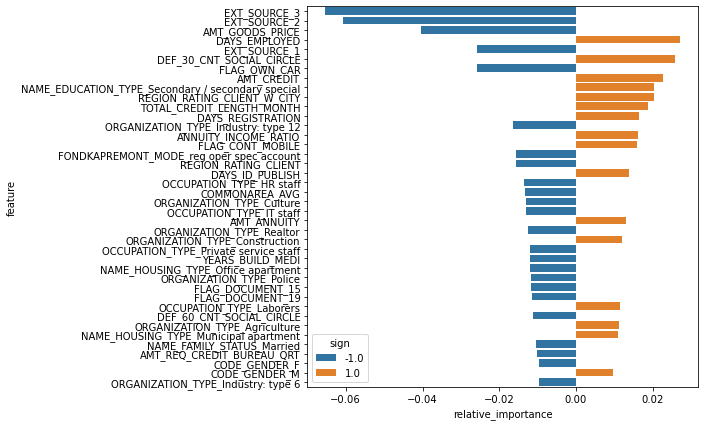

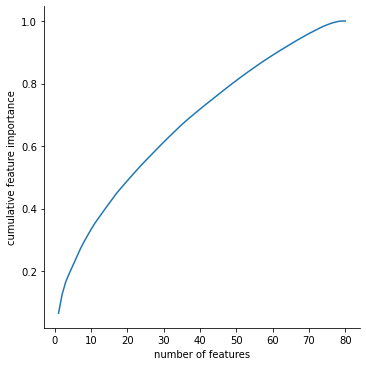

In [449]:
selected_features = features_busi[pipeline_lr_red_busi.named_steps['feature_selection'].get_support()]
A = features_importance_lg(pipeline_lr_red_busi.named_steps['estimator'],selected_features,plot=True,n_features_cum=80)

### Random Forest

In [451]:
pipeline_rdf_red_busi = create_pipeline_red_busi(RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'),
                                                 label='rdf',
                                                 best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_rdf_red_busi,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='rdf_red_select_from_model_busi'))

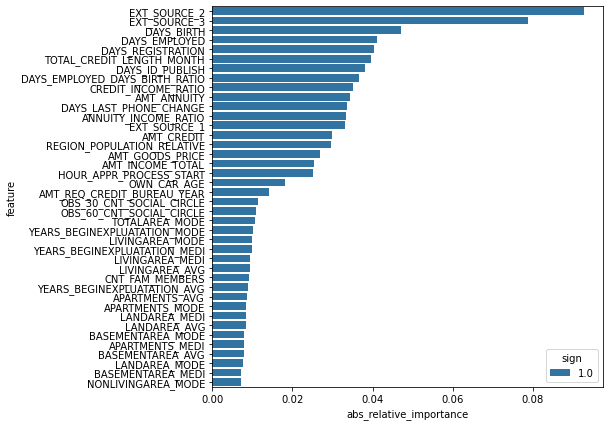

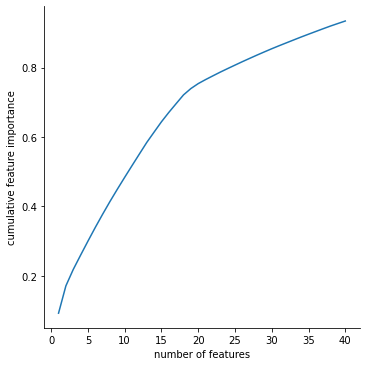

In [461]:
selected_features = features_busi[pipeline_rdf_red_busi.named_steps['feature_selection'].get_support()]
A = features_importance_rdf(pipeline_rdf_red_busi.named_steps['estimator'],selected_features,plot=True,n_features_cum=40)

### SGD 

In [454]:
pipeline_sgd_red_busi = create_pipeline_red_busi(SGDClassifier(class_weight='balanced',loss='modified_huber'),
                                                 label='sgd',
                                                 best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_sgd_red_busi,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='sgd_red_select_from_model_busi'))

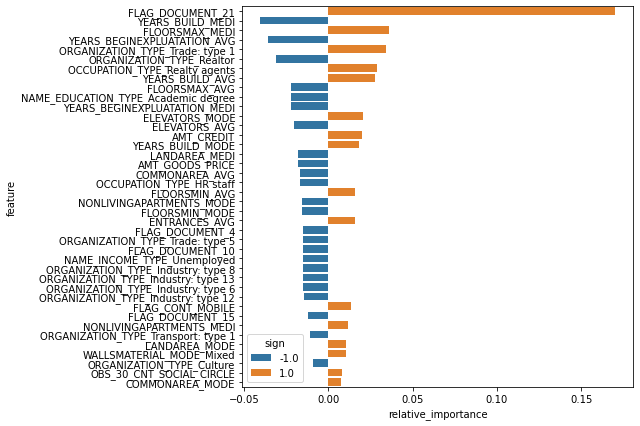

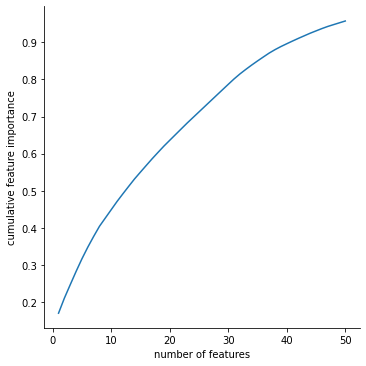

In [463]:
selected_features = features_busi[pipeline_sgd_red_busi.named_steps['feature_selection'].get_support()]
A = features_importance_lg(pipeline_sgd_red_busi.named_steps['estimator'],selected_features,plot=True,n_features_cum=50)

### LGB

In [455]:
pipeline_lgb_red_busi = create_pipeline_red_busi(LGBMClassifier(class_weight='balanced'),
                                                 label='lgb',
                                                 best_nb_feat = best_nb_feat)

scores = scores.append(compute_score(pipeline_lgb_red_busi,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lgb_red_select_from_model_busi'))

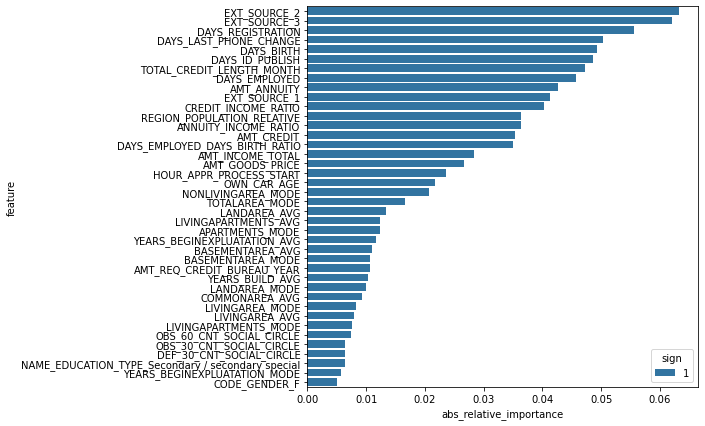

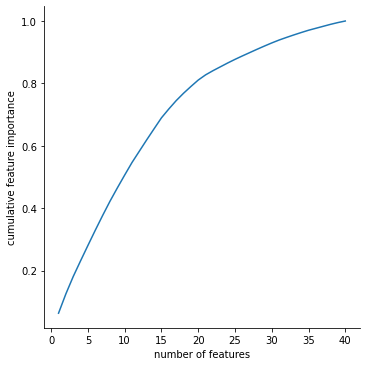

In [468]:
selected_features = features_busi[pipeline_lgb_red_busi.named_steps['feature_selection'].get_support()]
A = features_importance_rdf(pipeline_lgb_red_busi.named_steps['estimator'],selected_features,plot=True,n_features_cum=40)

In [481]:
scores.sort_values(by='f1_train',ascending=False)

,roc_auc_train,f1_train,roc_auc_test,f1_test
lgb,0.713487,0.258850,0.703182,0.250638
lgb_red_select_from_model_busi,0.717680,0.256807,0.701655,0.252615
lgb_col,0.712879,0.255730,0.703163,0.253562
lgb_red_select_from_model,0.712178,0.253944,0.702231,0.254969
lgb_red_select_from_model_col,0.712953,0.253857,0.706633,0.252549
lr_col,0.707265,0.247602,0.720713,0.246341
lr,0.708295,0.246446,0.720972,0.249256
lr_red_select_from_model_busi,0.708202,0.245802,0.723357,0.247473
lr_red_select_from_model,0.708623,0.245545,0.723833,0.247724
lr_red_select_from_model_col,0.708373,0.245455,0.724550,0.248789


In [471]:
### Kaggle submission

In [476]:
pipeline_lgb_red.fit(X,y)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                 max_features=50)),
                ('estimator', LGBMClassifier(class_weight='balanced'))])

In [477]:
kaggle_submit(pipeline_lgb_red,app_kaggle,'lgb.csv')

# Tuning the selected model

## Hyperparameter tuning

In [497]:
def show_performance(CV):
    print(f'best parameter : {CV.best_params_}')
    print("Cross validation results :")
    for mean, std, params in zip(
        CV.cv_results_['mean_test_score'], # score moyen
        CV.cv_results_['std_test_score'],  # écart-type du score
        CV.cv_results_['params']           # valeur de l'hyperparamètre
                                ):

             print("{} = {:.3f} (+/-{:.03f}) for {}".format(
                                                            CV.get_params()['scoring'],
                                                             mean,
                                                             std*2,
                                                             params
                                                            ))

### LGB

In [491]:
pipeline_lgb_tuning = Pipeline([('feature_eng', FunctionTransformer(func=create_features)),
                               ('imp', SimpleImputer()),
                               ('scaler' , StandardScaler()),
                               ('feature_selection', SelectFromModel(LGBMClassifier(class_weight='balanced'),max_features=best_nb_feat['lgb'])),
                               ('lgb', LGBMClassifier(class_weight='balanced'))])     

In [494]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'imp__strategy': ['median','mean','most_frequent'],
                                'lgb__num_leaves':[50,200,500],
                                'lgb__learning_rate':[0.001,0.01,1],
                                'lgb__n_estimators':[10,100,300]},
                  scoring = 'f1',
                  verbose=True,
                  cv=3)

In [495]:
CV_lgb.fit(X_train_under, y_train_under) 

Fitting 3 folds for each of 81 candidates, totalling 243 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 243 out of 243 | elapsed: 17.7min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                       ('imp', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                        max_features=50)),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'imp__strategy': ['median', 'mean', 'most_frequent'],
                         'lgb__learning_rate': [0.001, 0.01, 1],
                         'lgb__n_estimators': [10, 100, 300],
                         'lgb__num_leaves': [50, 200, 500]},
             scoring='f1', verbose

In [499]:
CV_lgb.best_params_

{'imp__strategy': 'most_frequent',
 'lgb__learning_rate': 0.01,
 'lgb__n_estimators': 300,
 'lgb__num_leaves': 50}

In [500]:
CV_lgb.best_estimator_.fit(X_train,y_train)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                 max_features=50)),
                ('lgb',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.01,
                                n_estimators=300, num_leaves=50))])

In [501]:
f1_score(y_test,CV_lgb.best_estimator_.predict(X_test))

0.2674977550050182

In [502]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'imp__strategy': ['most_frequent'],
                                'lgb__num_leaves':[10,25,50,75,100],
                                'lgb__learning_rate':[0.005,0.01,0.02],
                                'lgb__n_estimators':[300,500]},
                  scoring = 'f1',
                  verbose=True,
                  cv=3)

In [503]:
CV_lgb.fit(X_train_under, y_train_under) 

Fitting 3 folds for each of 30 candidates, totalling 90 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  90 out of  90 | elapsed:  7.8min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                       ('imp', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                        max_features=50)),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'imp__strategy': ['most_frequent'],
                         'lgb__learning_rate': [0.005, 0.01, 0.02],
                         'lgb__n_estimators': [300, 500],
                         'lgb__num_leaves': [10, 25, 50, 75, 100]},
             scoring='f1', verbose=True)

In [504]:
CV_lgb.best_params_

{'imp__strategy': 'most_frequent',
 'lgb__learning_rate': 0.01,
 'lgb__n_estimators': 300,
 'lgb__num_leaves': 75}

In [505]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'imp__strategy': ['most_frequent'],
                                'lgb__num_leaves':[70,80,90],
                                'lgb__learning_rate':[0.05,0.01,0.15],
                                'lgb__n_estimators':[200,300,400]},
                  scoring = 'f1',
                  verbose=True,
                  cv=3)

In [506]:
CV_lgb.fit(X_train_under, y_train_under) 

Fitting 3 folds for each of 27 candidates, totalling 81 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  81 out of  81 | elapsed:  6.6min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                       ('imp', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                        max_features=50)),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'imp__strategy': ['most_frequent'],
                         'lgb__learning_rate': [0.05, 0.01, 0.15],
                         'lgb__n_estimators': [200, 300, 400],
                         'lgb__num_leaves': [70, 80, 90]},
             scoring='f1', verbose=True)

In [507]:
CV_lgb.best_params_

{'imp__strategy': 'most_frequent',
 'lgb__learning_rate': 0.01,
 'lgb__n_estimators': 200,
 'lgb__num_leaves': 80}

In [508]:
CV_lgb.best_estimator_.fit(X_train,y_train)
f1_score(y_test,CV_lgb.best_estimator_.predict(X_test))

0.26384862699625783

In [509]:
kaggle_submit(pipeline_lgb_red,app_kaggle,'lgb.csv')

In [510]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'imp__strategy': ['most_frequent'],
                                'lgb__num_leaves':[75,80,85],
                                'lgb__learning_rate':[0.008,0.01,0.12],
                                'lgb__n_estimators':[150,200,250]},
                  scoring = 'f1',
                  verbose=True,
                  cv=3)

In [512]:
CV_lgb.fit(X_train_under, y_train_under)  

Fitting 3 folds for each of 27 candidates, totalling 81 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  81 out of  81 | elapsed:  5.3min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                       ('imp', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                        max_features=50)),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'imp__strategy': ['most_frequent'],
                         'lgb__learning_rate': [0.008, 0.01, 0.12],
                         'lgb__n_estimators': [150, 200, 250],
                         'lgb__num_leaves': [75, 80, 85]},
             scoring='f1', verbose=True)

In [513]:
CV_lgb.best_params_

{'imp__strategy': 'most_frequent',
 'lgb__learning_rate': 0.01,
 'lgb__n_estimators': 250,
 'lgb__num_leaves': 85}

In [514]:
CV_lgb.best_estimator_.fit(X_train,y_train)
f1_score(y_test,CV_lgb.best_estimator_.predict(X_test))

0.26700090671502485

In [515]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'imp__strategy': ['most_frequent'],
                                'lgb__num_leaves':[84,85,86],
                                'lgb__learning_rate':[0.01],
                                'lgb__n_estimators':[225,250,275]},
                  scoring = 'f1',
                  verbose=True,
                  cv=3)

In [516]:
CV_lgb.fit(X_train_under, y_train_under)  

Fitting 3 folds for each of 9 candidates, totalling 27 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  27 out of  27 | elapsed:  2.2min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                       ('imp', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                        max_features=50)),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'imp__strategy': ['most_frequent'],
                         'lgb__learning_rate': [0.01],
                         'lgb__n_estimators': [225, 250, 275],
                         'lgb__num_leaves': [84, 85, 86]},
             scoring='f1', verbose=True)

In [517]:
CV_lgb.best_params_

{'imp__strategy': 'most_frequent',
 'lgb__learning_rate': 0.01,
 'lgb__n_estimators': 250,
 'lgb__num_leaves': 84}

In [518]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'imp__strategy': ['most_frequent'],
                                'lgb__num_leaves':[83,84,85],
                                'lgb__learning_rate':[0.01],
                                'lgb__n_estimators':[240,250,260]},
                  scoring = 'f1',
                  verbose=True,
                  cv=3)

In [519]:
CV_lgb.fit(X_train_under, y_train_under)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  27 out of  27 | elapsed:  2.9min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('feature_eng',
                                        FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                       ('imp', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection',
                                        SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                        max_features=50)),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'imp__strategy': ['most_frequent'],
                         'lgb__learning_rate': [0.01],
                         'lgb__n_estimators': [240, 250, 260],
                         'lgb__num_leaves': [83, 84, 85]},
             scoring='f1', verbose=True)

In [520]:
CV_lgb.best_params_

{'imp__strategy': 'most_frequent',
 'lgb__learning_rate': 0.01,
 'lgb__n_estimators': 260,
 'lgb__num_leaves': 84}

In [521]:
CV_lgb.best_estimator_.fit(X_train,y_train)
f1_score(y_test,CV_lgb.best_estimator_.predict(X_test))

0.26868546359210316

In [524]:
kaggle_submit(CV_lgb.best_estimator_,app_kaggle,'lgb2.csv')

In [525]:
scores = scores.append(compute_score(CV_lgb.best_estimator_,
                                    X_train_under,
                                    y_train_under,
                                    X_test,
                                    y_test,
                                    cv = RepeatedStratifiedKFold(n_splits=4,n_repeats=2,random_state=1),
                                    label ='lgb_red_select_from_model_busi_opt'))

In [527]:
scores.sort_values(by='f1_test',ascending=False)

,roc_auc_train,f1_train,roc_auc_test,f1_test
lgb_red_select_from_model_busi_opt,0.722320,0.271892,0.713451,0.269774
lgb_red_select_from_model,0.712178,0.253944,0.702231,0.254969
lgb_col,0.712879,0.255730,0.703163,0.253562
lgb_red_select_from_model_busi,0.717680,0.256807,0.701655,0.252615
lgb_red_select_from_model_col,0.712953,0.253857,0.706633,0.252549
lgb,0.713487,0.258850,0.703182,0.250638
lr,0.708295,0.246446,0.720972,0.249256
lr_red_select_from_model_col,0.708373,0.245455,0.724550,0.248789
lr_red_select_from_model,0.708623,0.245545,0.723833,0.247724
lr_red_select_from_model_busi,0.708202,0.245802,0.723357,0.247473


In [536]:
np.arange(50,500,20)

array([ 50,  70,  90, 110, 130, 150, 170, 190, 210, 230, 250, 270, 290,
       310, 330, 350, 370, 390, 410, 430, 450, 470, 490])

### using random search

In [537]:
rdmCV_lgb = RandomizedSearchCV(pipeline_lgb_tuning,
                              param_distributions= {'imp__strategy': ['median','mean','most_frequent'],
                                                   'lgb__num_leaves':np.arange(20,200,10),
                                                   'lgb__learning_rate':np.logspace(-4,0,5),
                                                   'lgb__n_estimators':np.arange(50,500,20)},
                              scoring = 'f1',
                              cv=3,
                              n_iter=25
                              )

In [538]:
rdmCV_lgb.fit(X_train_under, y_train_under)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('feature_eng',
                                              FunctionTransformer(func=<function create_features at 0x000001A01935B3A0>)),
                                             ('imp', SimpleImputer()),
                                             ('scaler', StandardScaler()),
                                             ('feature_selection',
                                              SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                                              max_features=50)),
                                             ('lgb',
                                              LGBMClassifier(class_weight='balanced'))]),
                   n_ite...
                   param_distributions={'imp__strategy': ['median', 'mean',
                                                          'most_frequent'],
                                        'lgb__learning_rate':

In [539]:
rdmCV_lgb.best_params_

{'lgb__num_leaves': 80,
 'lgb__n_estimators': 270,
 'lgb__learning_rate': 0.01,
 'imp__strategy': 'most_frequent'}